In [ ]:

pip install opendatasets

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: revanthrev
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy


100%|██████████| 71.5M/71.5M [00:00<00:00, 1.74GB/s]

In [ ]:
import os
import numpy as np
import joblib
import cv2
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [ ]:
# === 1️⃣ Paths ===
input_dir = '/content/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset'
resized_dir = '/content/resized_dataset'
merged_dir = resized_dir + '_merged'   # created only if needed

IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

In [ ]:
# === 2️⃣ Resize Dataset to 224×224 ===
print("🔄 Resizing dataset to 224x224...")
if not os.path.exists(resized_dir):
    os.makedirs(resized_dir)

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith(IMAGE_EXTS):
            input_path = os.path.join(root, file)
            # keep the original relative path structure under resized_dir
            rel_path = os.path.relpath(root, input_dir)
            output_folder = os.path.join(resized_dir, rel_path)
            os.makedirs(output_folder, exist_ok=True)

            image = cv2.imread(input_path)
            if image is None:
                continue

            resized_image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_LINEAR)
            output_path = os.path.join(output_folder, file)
            cv2.imwrite(output_path, resized_image)

print("✅ Dataset resizing complete!")

🔄 Resizing dataset to 224x224...
✅ Dataset resizing complete!


In [ ]:
# === 2.a Detect nested structure (e.g., resized_dir contains 'train' and 'test') ===
import shutil

top_level = [d for d in os.listdir(resized_dir) if os.path.isdir(os.path.join(resized_dir, d))]
nested_class_dirs = set()

for top in top_level:
    top_path = os.path.join(resized_dir, top)
    # check subdirectories of top_path for classes (folders that contain images)
    for child in os.listdir(top_path):
        child_path = os.path.join(top_path, child)
        if os.path.isdir(child_path):
            # does child_path contain images?
            for f in os.listdir(child_path):
                if f.lower().endswith(IMAGE_EXTS):
                    nested_class_dirs.add(child)
                    break

use_dir = resized_dir
if nested_class_dirs:
    # If the top level looks like 'train'/'test' and second level are class names, merge them.
    print("Detected nested train/test splits — merging class folders into:", merged_dir)
    if os.path.exists(merged_dir):
        shutil.rmtree(merged_dir)
    os.makedirs(merged_dir, exist_ok=True)

    # For each split (train/test/val), copy images into merged_dir/<class_name>/
    for top in top_level:
        top_path = os.path.join(resized_dir, top)
        if not os.path.isdir(top_path):
            continue
        for class_name in os.listdir(top_path):
            class_path = os.path.join(top_path, class_name)
            if not os.path.isdir(class_path):
                continue
            dest_class_folder = os.path.join(merged_dir, class_name)
            os.makedirs(dest_class_folder, exist_ok=True)
            for fname in os.listdir(class_path):
                if not fname.lower().endswith(IMAGE_EXTS):
                    continue
                src = os.path.join(class_path, fname)
                # avoid name collisions by prefixing with split name if same filename exists
                dest_fname = f"{top}_{fname}" if os.path.exists(os.path.join(dest_class_folder, fname)) else fname
                dst = os.path.join(dest_class_folder, dest_fname)
                shutil.copy2(src, dst)

    use_dir = merged_dir
else:
    print("No nested train/test detected. Using:", resized_dir)

Detected nested train/test splits — merging class folders into: /content/resized_dataset_merged


In [ ]:
# === 3️⃣ Data Generator ===
datagen = ImageDataGenerator(rescale=1./255)
generator = datagen.flow_from_directory(
    use_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# === 4️⃣ VGG16 Feature Extractor ===
print("\n🔧 Loading VGG16 model for feature extraction...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

print("\n🔍 Extracting features...")
features = feature_extractor.predict(generator, verbose=1)
labels = generator.classes
class_indices = generator.class_indices
# class_indices maps class_name -> numeric_label (e.g. {'Mild Demented':0, ...})
print("Class indices (class_name -> numeric_label):", class_indices)

# Create numeric -> class_name map
label_map = {v: k for k, v in class_indices.items()}
class_names = [label_map[i] for i in sorted(label_map.keys())]
num_classes = len(class_names)

print("✅ Feature extraction complete!")
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print("Detected classes (in numeric order):", class_names)
feature_extractor.summary()


Found 11519 images belonging to 4 classes.

🔧 Loading VGG16 model for feature extraction...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔍 Extracting features...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


360/360 ━━━━━━━━━━━━━━━━━━━━ 81s 191ms/step
Class indices (class_name -> numeric_label): {'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}
✅ Feature extraction complete!
Features shape: (11519, 512)
Labels shape: (11519,)
Detected classes (in numeric order): ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# === 5️⃣ Train–Test Split ===
X_train, X_val, y_train, y_val = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

# === 6️⃣ Feature Normalization ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


🚀 Training Multi-Class SVM Classifier...
✅ SVM training complete!

🚀 Training XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:24:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost training complete!

🚀 Training Gaussian Naive Bayes Classifier...
✅ GNB training complete!
💾 Saved base models and scaler/label map.

📈 SVM Accuracy: 98.31%
                      precision    recall  f1-score   support

     Mild Impairment       0.99      0.98      0.99       548
 Moderate Impairment       1.00      1.00      1.00       514
       No Impairment       0.98      0.98      0.98       640
Very Mild Impairment       0.97      0.98      0.97       602

            accuracy                           0.98      2304
           macro avg       0.98      0.98      0.98      2304
        weighted avg       0.98      0.98      0.98      2304


📈 XGBoost Accuracy: 91.58%
                      precision    recall  f1-score   support

     Mild Impairment       0.95      0.93      0.94       548
 Moderate Impairment       1.00      1.00      1.00       514
       No Impairment       0.88      0.90      0.89       640
Very Mild Impairment       0.85      0.86      0.85      

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:27:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:33:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:35:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:37:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:39:27] WARNING: /w

✅ Stacking Ensemble training complete!

🏆 Stacking Ensemble Accuracy: 98.26%
                      precision    recall  f1-score   support

     Mild Impairment       0.99      0.98      0.99       548
 Moderate Impairment       1.00      1.00      1.00       514
       No Impairment       0.98      0.98      0.98       640
Very Mild Impairment       0.97      0.97      0.97       602

            accuracy                           0.98      2304
           macro avg       0.98      0.98      0.98      2304
        weighted avg       0.98      0.98      0.98      2304

💾 Saved: stacking_vgg16_multiclass.pkl
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🧠 Voting Ensemble Prediction: Moderate Impairment
🗳️ Votes → SVM: Moderate Impairment, XGB: Moderate Impairment, GNB: Moderate Impairment


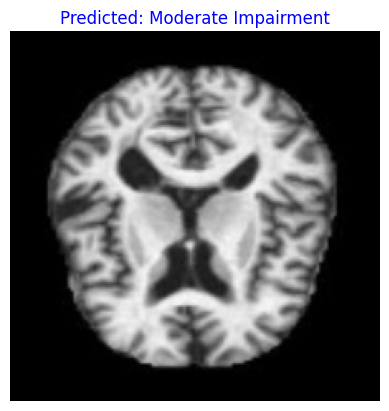

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

🏆 Stacking Ensemble Prediction: Moderate Impairment


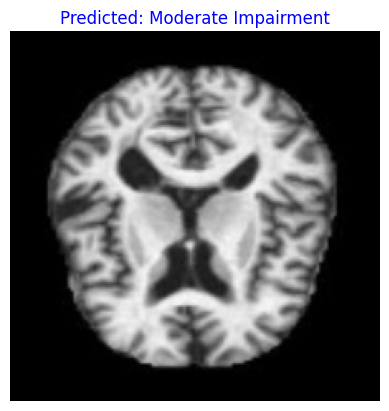

'Moderate Impairment'

In [ ]:
# === 7️⃣ Train Multi-Class SVM ===
print("\n🚀 Training Multi-Class SVM Classifier...")
from sklearn.svm import SVC
svm_clf = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    decision_function_shape='ovr',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm_clf.fit(X_train, y_train)
print("✅ SVM training complete!")

# === 🧠 Add XGBoost and Gaussian Naive Bayes Classifiers ===
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

print("\n🚀 Training XGBoost Classifier...")
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)
print("✅ XGBoost training complete!")

print("\n🚀 Training Gaussian Naive Bayes Classifier...")
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)
print("✅ GNB training complete!")

# === 💾 Save Base Models ===
import joblib
joblib.dump(svm_clf, 'svm_vgg16_multiclass.pkl')
joblib.dump(xgb_clf, 'xgb_vgg16_multiclass.pkl')
joblib.dump(gnb_clf, 'gnb_vgg16_multiclass.pkl')
joblib.dump(scaler, 'vgg16_scaler.pkl')
joblib.dump(label_map, 'label_map.pkl')
print("💾 Saved base models and scaler/label map.")

# === 📊 Evaluate Base Models ===
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_val, y_val, name):
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"\n📈 {name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_val, preds, target_names=class_names))
    return preds

svm_preds = evaluate_model(svm_clf, X_val, y_val, "SVM")
xgb_preds = evaluate_model(xgb_clf, X_val, y_val, "XGBoost")
gnb_preds = evaluate_model(gnb_clf, X_val, y_val, "GNB")

# === ⚖️ Ensemble (Simple Majority Voting) ===
print("\n🤝 Performing Ensemble (Simple Voting)...")
ensemble_preds = []
for i in range(len(y_val)):
    votes = [svm_preds[i], xgb_preds[i], gnb_preds[i]]
    final_vote = max(set(votes), key=votes.count)
    ensemble_preds.append(final_vote)

ensemble_acc = accuracy_score(y_val, ensemble_preds)
print(f"\n✅ Ensemble Model (Majority Voting) Accuracy: {ensemble_acc*100:.2f}%")
print(classification_report(y_val, ensemble_preds, target_names=class_names))

# === 🔥 NEW: Stacking Ensemble Technique ===
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("\n🚀 Training Stacking Ensemble Classifier...")
base_learners = [
    ('svm', svm_clf),
    ('xgb', xgb_clf),
    ('gnb', gnb_clf)
]

meta_learner = LogisticRegression(max_iter=1000, random_state=42)

stacked_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method='predict_proba',  # uses probabilities from base models
    passthrough=False
)

stacked_clf.fit(X_train, y_train)
print("✅ Stacking Ensemble training complete!")

# Evaluate Stacking Ensemble
stacked_preds = stacked_clf.predict(X_val)
stacked_acc = accuracy_score(y_val, stacked_preds)
print(f"\n🏆 Stacking Ensemble Accuracy: {stacked_acc*100:.2f}%")
print(classification_report(y_val, stacked_preds, target_names=class_names))

# 💾 Save Stacking Model
joblib.dump(stacked_clf, 'stacking_vgg16_multiclass.pkl')
print("💾 Saved: stacking_vgg16_multiclass.pkl")

# === 🧩 Ensemble Inference Function (with Voting & Stacking) ===
def predict_single_image_ensemble(img_path, use_stacking=False, show_image=True):
    """Predict Alzheimer class using Ensemble (Voting or Stacking)."""
    import cv2, numpy as np, matplotlib.pyplot as plt, os

    if not os.path.exists(img_path):
        raise FileNotFoundError(img_path)

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Could not read image: " + img_path)

    # Preprocess image
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_input = img_resized.astype('float32') / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    # Extract and scale features
    feature = feature_extractor.predict(img_input)
    feature_scaled = scaler.transform(feature)

    if use_stacking:
        final_pred = stacked_clf.predict(feature_scaled)[0]
        predicted_label = label_map[int(final_pred)]
        print(f"\n🏆 Stacking Ensemble Prediction: {predicted_label}")
    else:
        svm_pred = svm_clf.predict(feature_scaled)[0]
        xgb_pred = xgb_clf.predict(feature_scaled)[0]
        gnb_pred = gnb_clf.predict(feature_scaled)[0]
        votes = [svm_pred, xgb_pred, gnb_pred]
        final_vote = max(set(votes), key=votes.count)
        predicted_label = label_map[int(final_vote)]
        print(f"\n🧠 Voting Ensemble Prediction: {predicted_label}")
        print(f"🗳️ Votes → SVM: {label_map[int(svm_pred)]}, XGB: {label_map[int(xgb_pred)]}, GNB: {label_map[int(gnb_pred)]}")

    if show_image:
        plt.imshow(img_resized)
        plt.axis('off')
        plt.title(f"Predicted: {predicted_label}", fontsize=12, color='blue')
        plt.show()

    return predicted_label

# === 🧪 Example usage ===
test_image = "/content/resized_dataset/test/Moderate Impairment/14.jpg"

# 🔹 Option 1: Majority Voting
predict_single_image_ensemble(test_image, use_stacking=False)

# 🔹 Option 2: Stacking Ensemble
predict_single_image_ensemble(test_image, use_stacking=True)


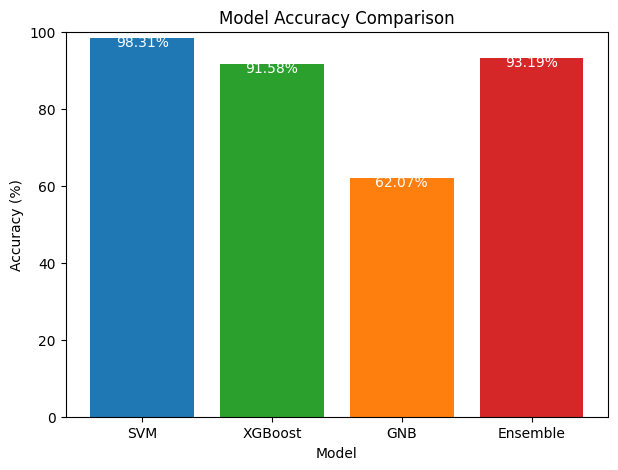

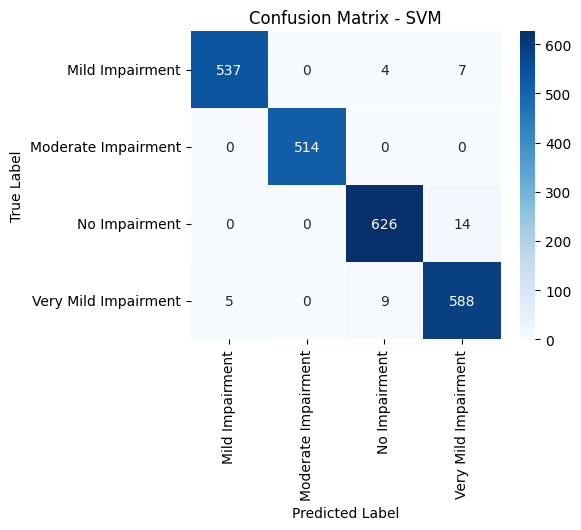

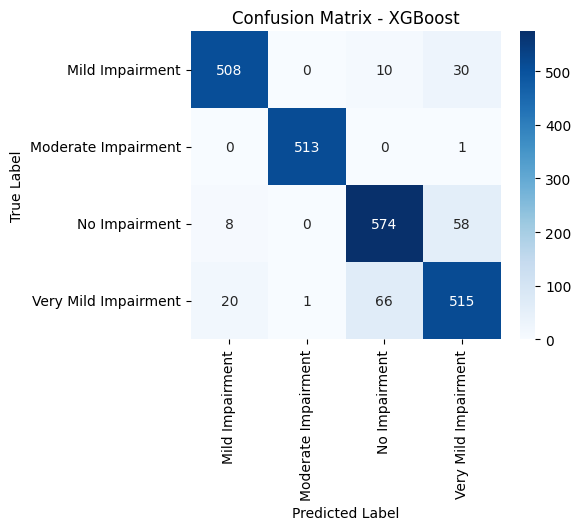

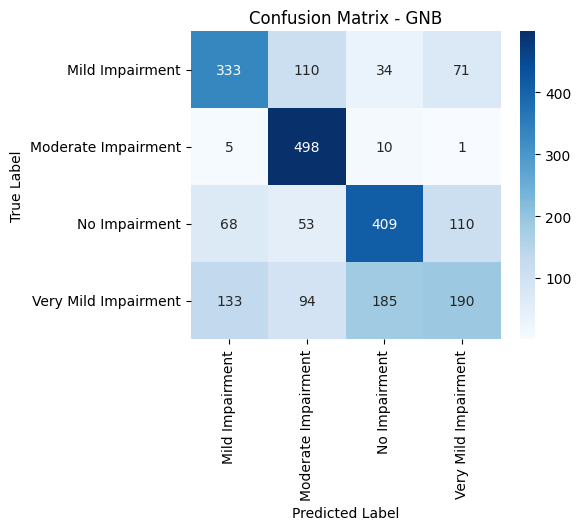

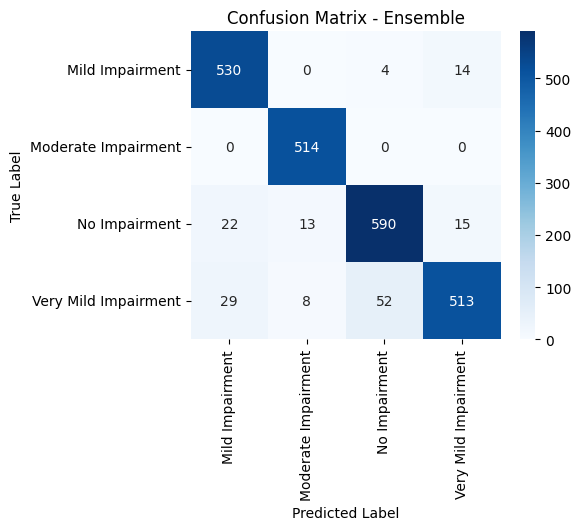

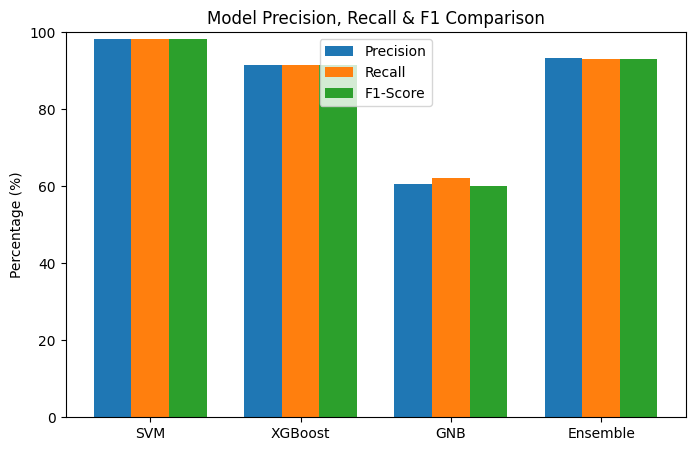

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# === 📊 1️⃣ Compute model accuracies ===
svm_acc = accuracy_score(y_val, svm_preds)
xgb_acc = accuracy_score(y_val, xgb_preds)
gnb_acc = accuracy_score(y_val, gnb_preds)
ensemble_acc = accuracy_score(y_val, ensemble_preds)

# === 📈 2️⃣ Plot Accuracy Comparison Bar Chart ===
plt.figure(figsize=(7, 5))
models = ['SVM', 'XGBoost', 'GNB', 'Ensemble']
accuracies = [svm_acc * 100, xgb_acc * 100, gnb_acc * 100, ensemble_acc * 100]
bars = plt.bar(models, accuracies, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height - 3, f'{height:.2f}%', ha='center', va='bottom', color='white', fontsize=10)
plt.show()

# === 🧩 3️⃣ Plot Confusion Matrices ===
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_val, svm_preds, "Confusion Matrix - SVM")
plot_confusion_matrix(y_val, xgb_preds, "Confusion Matrix - XGBoost")
plot_confusion_matrix(y_val, gnb_preds, "Confusion Matrix - GNB")
plot_confusion_matrix(y_val, ensemble_preds, "Confusion Matrix - Ensemble")

# === 📉 4️⃣ Precision, Recall, F1 Visualization (Optional) ===
from sklearn.metrics import precision_recall_fscore_support

def plot_metrics_comparison(models, preds_list, y_true):
    metrics = ['Precision', 'Recall', 'F1-Score']
    results = []
    for preds in preds_list:
        p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average='weighted')
        results.append([p*100, r*100, f1*100])

    results = np.array(results)
    x = np.arange(len(models))
    width = 0.25

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, results[:, 0], width, label='Precision')
    plt.bar(x, results[:, 1], width, label='Recall')
    plt.bar(x + width, results[:, 2], width, label='F1-Score')

    plt.xticks(x, models)
    plt.ylabel('Percentage (%)')
    plt.title('Model Precision, Recall & F1 Comparison')
    plt.legend()
    plt.ylim(0, 100)
    plt.show()

plot_metrics_comparison(
    ['SVM', 'XGBoost', 'GNB', 'Ensemble'],
    [svm_preds, xgb_preds, gnb_preds, ensemble_preds],
    y_val
)


In [ ]:
# === ROC–AUC Curve Comparison (One-vs-Rest for Multiclass) ===
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize the true labels for multiclass ROC computation
y_val_bin = label_binarize(y_val, classes=np.arange(len(class_names)))
n_classes = y_val_bin.shape[1]

# Helper function to compute ROC data for a classifier
def compute_roc_data(model, X_val, y_true_bin):
    y_score = model.predict_proba(X_val)
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Compute micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    return fpr, tpr, roc_auc

# Compute ROC data for all classifiers
fpr_svm, tpr_svm, roc_svm = compute_roc_data(svm_clf, X_val, y_val_bin)
fpr_xgb, tpr_xgb, roc_xgb = compute_roc_data(xgb_clf, X_val, y_val_bin)
fpr_gnb, tpr_gnb, roc_gnb = compute_roc_data(gnb_clf, X_val, y_val_bin)

# === 🎯 Ensemble ROC (average of probabilities from all three) ===
svm_probs = svm_clf.predict_proba(X_val)
xgb_probs = xgb_clf.predict_proba(X_val)
gnb_probs = gnb_clf.predict_proba(X_val)
ensemble_probs = (svm_probs + xgb_probs + gnb_probs) / 3.0

fpr_ens, tpr_ens, roc_ens = dict(), dict(), dict()
for i in range(n_classes):
    fpr_ens[i], tpr_ens[i], _ = roc_curve(y_val_bin[:, i], ensemble_probs[:, i])
    roc_ens[i] = auc(fpr_ens[i], tpr_ens[i])
fpr_ens["micro"], tpr_ens["micro"], _ = roc_curve(y_val_bin.ravel(), ensemble_probs.ravel())
roc_ens["micro"] = auc(fpr_ens["micro"], tpr_ens["micro"])

# === 📉 Plot Micro-Averaged ROC Curves for All Models ===
plt.figure(figsize=(7, 6))
plt.plot(fpr_svm["micro"], tpr_svm["micro"], label=f"SVM (AUC = {roc_svm['micro']:.3f})", color='#1f77b4')
plt.plot(fpr_xgb["micro"], tpr_xgb["micro"], label=f"XGBoost (AUC = {roc_xgb['micro']:.3f})", color='#2ca02c')
plt.plot(fpr_gnb["micro"], tpr_gnb["micro"], label=f"GNB (AUC = {roc_gnb['micro']:.3f})", color='#ff7f0e')
plt.plot(fpr_ens["micro"], tpr_ens["micro"], label=f"Ensemble (AUC = {roc_ens['micro']:.3f})", color='#d62728', linewidth=2.2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Averaged ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


AttributeError: 'SVC' object has no attribute 'support_vectors_'

In [ ]:
import gradio as gr
import cv2
import numpy as np
import joblib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ======================
# Load Model Artifacts
# ======================
# The model artifacts were saved directly in /content/ and with specific names.
# Update paths and filenames to match the saved files.

scaler = joblib.load("/content/vgg16_scaler.pkl")
stacked_model = joblib.load("/content/stacking_vgg16_multiclass.pkl")
label_map = joblib.load("/content/label_map.pkl")

class_names = [label_map[i] for i in sorted(label_map)]

# ======================
# Load VGG16 Feature Extractor
# ======================
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ======================
# Prediction Function
# ======================
def predict_alzheimer(image):
    if image is None:
        return "No image provided"

    # Resize & preprocess
    img = cv2.resize(image, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Feature extraction
    features = feature_extractor.predict(img)
    features_scaled = scaler.transform(features)

    # Prediction
    pred = stacked_model.predict(features_scaled)[0]
    confidence = np.max(stacked_model.predict_proba(features_scaled)) * 100

    return f"Prediction: {class_names[pred]}\nConfidence: {confidence:.2f}%"

# ======================
# Gradio Interface
# ======================
interface = gr.Interface(
    fn=predict_alzheimer,
    inputs=gr.Image(type="numpy", label="Upload MRI Image"),
    outputs=gr.Textbox(label="Result"),
    title="Alzheimer Disease Detection System",
    description=(
        "Upload a brain MRI image to classify Alzheimer stages using "
        "VGG16 feature extraction and a stacking ensemble model."
    ),
    allow_flagging="never"
)

interface.launch()


FileNotFoundError: [Errno 2] No such file or directory: '/content/vgg16_scaler.pkl'

In [ ]:
import gradio as gr
import cv2
import numpy as np
import joblib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ======================
# Load Model Artifacts
# ======================
scaler = joblib.load("/content/vgg16_scaler.pkl")
stacked_model = joblib.load("/content/stacking_vgg16_multiclass.pkl")
label_map = joblib.load("/content/label_map.pkl")

class_names = [label_map[i] for i in sorted(label_map)]

# ======================
# Load VGG16 Feature Extractor
# ======================
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ======================
# Prediction Function (LOGIC UNCHANGED)
# ======================
def predict_alzheimer(image):
    if image is None:
        return "<h2 style='color:red;'>No image provided</h2>"

    img = cv2.resize(image, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    features = feature_extractor.predict(img, verbose=0)
    features_scaled = scaler.transform(features)

    pred = stacked_model.predict(features_scaled)[0]
    confidence = np.max(stacked_model.predict_proba(features_scaled)) * 100

    label = class_names[pred]

    # BIG & HIGHLIGHTED RESULT
    return f"""
    <div style="
        text-align:center;
        padding:25px;
        border-radius:15px;
        background-color:#f5f5f5;
        box-shadow:0px 0px 15px rgba(0,0,0,0.2);
    ">
        <h1 style="font-size:36px; color:#2c3e50;">
            🧠 {label}
        </h1>
        <h2 style="font-size:26px; color:#27ae60;">
            Confidence: {confidence:.2f}%
        </h2>
    </div>
    """

# ======================
# Gradio Interface (ONLY OUTPUT CHANGED)
# ======================
interface = gr.Interface(
    fn=predict_alzheimer,
    inputs=gr.Image(type="numpy", label="Upload MRI Image"),
    outputs=gr.HTML(label="Result"),   # 🔥 HTML instead of Textbox
    title="Alzheimer Disease Detection System",
    description=(
        "Upload a brain MRI image to classify Alzheimer stages using "
        "VGG16 feature extraction and a stacking ensemble model."
    ),
    allow_flagging="never"
)

interface.launch()


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://10dcaf2a58951ff67f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import cv2
import numpy as np
import joblib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ======================
# Load Model Artifacts
# ======================
scaler = joblib.load("/content/vgg16_scaler.pkl")
stacked_model = joblib.load("/content/stacking_vgg16_multiclass.pkl")
label_map = joblib.load("/content/label_map.pkl")

class_names = [label_map[i] for i in sorted(label_map)]

# ======================
# Load VGG16 Feature Extractor
# ======================
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ======================
# Prediction Function (UNCHANGED LOGIC)
# ======================
def predict_alzheimer(image):
    if image is None:
        return "<h2 style='color:red;'>No image provided</h2>"

    img = cv2.resize(image, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    features = feature_extractor.predict(img, verbose=0)
    features_scaled = scaler.transform(features)

    pred = stacked_model.predict(features_scaled)[0]
    confidence = np.max(stacked_model.predict_proba(features_scaled)) * 100

    label = class_names[pred]

    return f"""
    <div style="
        text-align:center;
        padding:30px;
        border-radius:18px;
        background: linear-gradient(135deg, #ffffff, #f1f8ff);
        box-shadow: 0px 8px 25px rgba(0,0,0,0.15);
    ">
        <h1 style="font-size:38px; color:#2c3e50; margin-bottom:10px;">
            🧠 {label}
        </h1>
        <h2 style="font-size:26px; color:#1e8449;">
            Confidence: {confidence:.2f}%
        </h2>
    </div>
    """

# ======================
# Custom CSS (BACKGROUND FIX)
# ======================
custom_css = """
body {
    background: linear-gradient(135deg, #74ebd5, #ACB6E5);
}

.gradio-container {
    max-width: 900px;
    margin: auto;
}

footer {
    display: none !important;
}
"""

# ======================
# Gradio Interface
# ======================
with gr.Blocks(css=custom_css) as demo:
    gr.Markdown(
        "<h1 style='text-align:center; color:#2c3e50;'>🧠 Alzheimer Disease Detection System</h1>"
    )
    gr.Markdown(
        "<h3 style='text-align:center; color:#34495e;'>Upload a brain MRI image for AI-based diagnosis</h3>"
    )

    with gr.Row():
        image_input = gr.Image(type="numpy", label="Upload MRI Image")
        result_output = gr.HTML(label="Result")

    analyze_btn = gr.Button("🔍 Analyze MRI")
    analyze_btn.click(predict_alzheimer, image_input, result_output)

    gr.Markdown(
        "<p style='text-align:center; color:#555;'>⚠️ For academic and research purposes only</p>"
    )

demo.launch()


/tmp/ipython-input-815735621.py:87: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff9d32fd14e84d1774.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "<h1 style='text-align:center; color:white;'>🧠 Alzheimer Disease Detection System</h1>"
    )
    gr.Markdown(
        "<p style='text-align:center; color:#eaeaea;'>Upload a brain MRI image for AI-based diagnosis</p>"
    )

    with gr.Row():
        image_input = gr.Image(type="numpy", label="Upload MRI Image")
        result_output = gr.HTML(label="Result")

    analyze_btn = gr.Button("🔍 Analyze MRI")
    analyze_btn.click(predict_alzheimer, image_input, result_output)

    gr.Markdown(
        "<p style='text-align:center; color:#f1f1f1;'>⚠️ For academic and research purposes only</p>"
    )

demo.launch()


/tmp/ipython-input-1856481574.py:1: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipython-input-1856481574.py:1: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://795944075f339dbe81.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import cv2
import numpy as np
import joblib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ======================
# Load Model Artifacts
# ======================
scaler = joblib.load("/content/vgg16_scaler.pkl")
stacked_model = joblib.load("/content/stacking_vgg16_multiclass.pkl")
label_map = joblib.load("/content/label_map.pkl")

class_names = [label_map[i] for i in sorted(label_map)]

# ======================
# Load VGG16 Feature Extractor
# ======================
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ======================
# Prediction Function (UNCHANGED LOGIC)
# ======================
def predict_alzheimer(image):
    if image is None:
        return "<h2 style='color:red;'>No image provided</h2>"

    img = cv2.resize(image, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    features = feature_extractor.predict(img, verbose=0)
    features_scaled = scaler.transform(features)

    pred = stacked_model.predict(features_scaled)[0]
    confidence = np.max(stacked_model.predict_proba(features_scaled)) * 100
    label = class_names[pred]

    return f"""
    <div class="result-card">
        <h1>🧠 {label}</h1>
        <h2>Confidence: {confidence:.2f}%</h2>
    </div>
    """

# ======================
# Custom CSS (3D Brain Background + Glass Effect)
# ======================
custom_css = """
/* Force background image even in dark mode */
body, .dark body {
    background-image: url('https://images.unsplash.com/photo-1581091870622-3e2f48c8e1a7');
    background-size: cover;
    background-position: center;
    background-repeat: no-repeat;
    background-attachment: fixed;
}

/* Dark glass overlay */
body::before {
    content: "";
    position: fixed;
    inset: 0;
    background: rgba(8, 10, 20, 0.75);
    z-index: -1;
}

/* Main container */
.gradio-container {
    max-width: 900px;
    margin: auto;
}

/* Result card */
.result-card {
    text-align: center;
    padding: 30px;
    border-radius: 22px;
    background: linear-gradient(135deg, #ffffff, #f1f8ff);
    box-shadow: 0 15px 40px rgba(0,0,0,0.35);
}

.result-card h1 {
    font-size: 36px;
    color: #2c3e50;
    margin-bottom: 10px;
}

.result-card h2 {
    font-size: 24px;
    color: #1e8449;
}

/* Button styling */
button {
    background: linear-gradient(135deg, #00c6ff, #0072ff) !important;
    color: white !important;
    font-size: 16px !important;
    border-radius: 14px !important;
}

/* Headings */
h1, h2, h3, p {
    color: #ffffff;
}

/* Hide footer */
footer {
    display: none !important;
}
"""

# ======================
# Gradio Interface
# ======================
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "<h1 style='text-align:center;'>🧠 Alzheimer Disease Detection System</h1>"
    )
    gr.Markdown(
        "<p style='text-align:center; font-size:16px;'>Upload a brain MRI image for AI-based diagnosis</p>"
    )

    with gr.Row():
        image_input = gr.Image(type="numpy", label="Upload MRI Image")
        result_output = gr.HTML(label="Result")

    analyze_btn = gr.Button("🔍 Analyze MRI")
    analyze_btn.click(predict_alzheimer, image_input, result_output)

    gr.Markdown(
        "<p style='text-align:center; font-size:13px;'>⚠️ For academic and research purposes only</p>"
    )

demo.launch()


/tmp/ipython-input-3711149308.py:125: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipython-input-3711149308.py:125: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://374100958d3f0f77ea.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import cv2
import numpy as np
import joblib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ======================
# Load Model Artifacts
# ======================
scaler = joblib.load("/content/vgg16_scaler.pkl")
stacked_model = joblib.load("/content/stacking_vgg16_multiclass.pkl")
label_map = joblib.load("/content/label_map.pkl")

class_names = [label_map[i] for i in sorted(label_map)]

# ======================
# Load VGG16 Feature Extractor
# ======================
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# ======================
# Prediction Function (UNCHANGED)
# ======================
def predict_alzheimer(image):
    if image is None:
        return "<h2 style='color:red;'>No image provided</h2>"

    img = cv2.resize(image, (224,224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    features = feature_extractor.predict(img, verbose=0)
    features_scaled = scaler.transform(features)

    pred = stacked_model.predict(features_scaled)[0]
    confidence = np.max(stacked_model.predict_proba(features_scaled)) * 100
    label = class_names[pred]

    return f"""
    <div class="result-card">
        <h1>🧠 {label}</h1>
        <h2>Confidence: {confidence:.2f}%</h2>
    </div>
    """

# ======================
# CSS — THIS IS THE KEY FIX
# ======================
custom_css = """
/* Attach background to Gradio container */
.gradio-container {
    position: relative;
    max-width: 900px;
    margin: auto;
    z-index: 1;
}

/* Background image layer */
.gradio-container::before {
    content: "";
    position: fixed;
    inset: 0;
    background-image: url("https://images.unsplash.com/photo-1581091870622-3e2f48c8e1a7");
    background-size: cover;
    background-position: center;
    background-repeat: no-repeat;
    z-index: -2;
}

/* Dark overlay for readability */
.gradio-container::after {
    content: "";
    position: fixed;
    inset: 0;
    background: rgba(5, 8, 20, 0.75);
    z-index: -1;
}

/* Result card */
.result-card {
    text-align: center;
    padding: 30px;
    border-radius: 22px;
    background: linear-gradient(135deg, #ffffff, #eef4ff);
    box-shadow: 0 15px 40px rgba(0,0,0,0.35);
}

.result-card h1 {
    font-size: 36px;
    color: #2c3e50;
}

.result-card h2 {
    font-size: 24px;
    color: #1e8449;
}

/* Button */
button {
    background: linear-gradient(135deg, #00c6ff, #0072ff) !important;
    color: white !important;
    border-radius: 14px !important;
    font-size: 16px !important;
}

/* Text color */
h1, h2, h3, p, label {
    color: white !important;
}

/* Hide footer */
footer {
    display: none !important;
}
"""

# ======================
# Gradio Interface
# ======================
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    gr.Markdown("<h1 style='text-align:center;'>🧠 Alzheimer Disease Detection System</h1>")
    gr.Markdown("<p style='text-align:center;'>Upload a brain MRI image for AI-based diagnosis</p>")

    with gr.Row():
        image_input = gr.Image(type="numpy", label="Upload MRI Image")
        result_output = gr.HTML(label="Result")

    analyze_btn = gr.Button("🔍 Analyze MRI")
    analyze_btn.click(predict_alzheimer, image_input, result_output)

    gr.Markdown("<p style='text-align:center; font-size:13px;'>⚠️ For academic and research purposes only</p>")

demo.launch()


/tmp/ipython-input-85700460.py:124: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipython-input-85700460.py:124: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://801bc1df84d645c425.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
